# A9 KMeans Clustering and PCA

Zachary Fletcher

# Task 1

In [41]:
#imports
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn import datasets

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
#import dataset
df = pd.read_csv('https://raw.githubusercontent.com/matthewpecsok/4482_fall_2022/main/data/titanic_cleaned.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  714 non-null    int64  
 1   Pclass    714 non-null    int64  
 2   Sex       714 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     714 non-null    int64  
 5   Parch     714 non-null    int64  
 6   Fare      714 non-null    float64
 7   Cabin     714 non-null    object 
 8   Embarked  714 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 50.3+ KB


In [4]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000
mean,0.406162,2.236695,29.699118,0.512605,0.431373,34.694514
std,0.491460,0.838250,14.526497,0.929783,0.853289,52.918930
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,20.125000,0.000000,0.000000,8.050000
50%,0.000000,2.000000,28.000000,0.000000,0.000000,15.741700
75%,1.000000,3.000000,38.000000,1.000000,1.000000,33.375000
max,1.000000,3.000000,80.000000,5.000000,6.000000,512.329200


In [5]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,missing,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,missing,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,missing,S


In [6]:
# drop cabin column
df.drop('Cabin', axis=1, inplace=True)

# Task 2

In [9]:
# Scale the data
df_enc = pd.get_dummies(df, drop_first=True)
df_scaled = StandardScaler().fit_transform(df_enc)
df_scaled = pd.DataFrame(df_scaled, columns=df_enc.columns)
df_scaled.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Embarked_missing
0,-0.82702,0.911232,-0.530377,0.524570,-0.505895,-0.518978,0.759051,-0.202031,0.537409,-0.053
1,1.20916,-1.476364,0.571831,0.524570,-0.505895,0.691897,-1.317434,-0.202031,-1.860779,-0.053
2,1.20916,0.911232,-0.254825,-0.551703,-0.505895,-0.506214,-1.317434,-0.202031,0.537409,-0.053
3,1.20916,-1.476364,0.365167,0.524570,-0.505895,0.348049,-1.317434,-0.202031,0.537409,-0.053
4,-0.82702,0.911232,0.365167,-0.551703,-0.505895,-0.503850,0.759051,-0.202031,0.537409,-0.053


# Task 3

In [10]:
# find best K
inertia_lst = []
model_lst = []
for k in range(1, 21):
  model = KMeans(n_clusters=k).fit(df_scaled)
  inertia_lst.append(model.inertia_)
  model_lst.append(model)

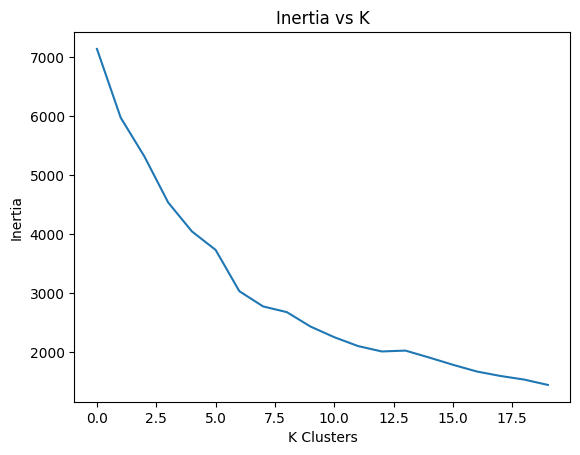

In [11]:
#plot Results for elbow method
plt.plot(inertia_lst)
plt.title('Inertia vs K')
plt.xlabel('K Clusters')
plt.ylabel('Inertia')
plt.show()

It looks like the best number of k clusters is about 5-6

# Task 4

## Task 4a

In [12]:
#fit and predict Kmeans with k = 6
kmeans = KMeans(n_clusters=6).fit(df_scaled)
kmeans_pred = kmeans.predict(df_scaled)

In [14]:
# add predicted clusters into df as new column 'predicted clusters'
df_scaled['predicted clusters'] = kmeans_pred

## Task 4b

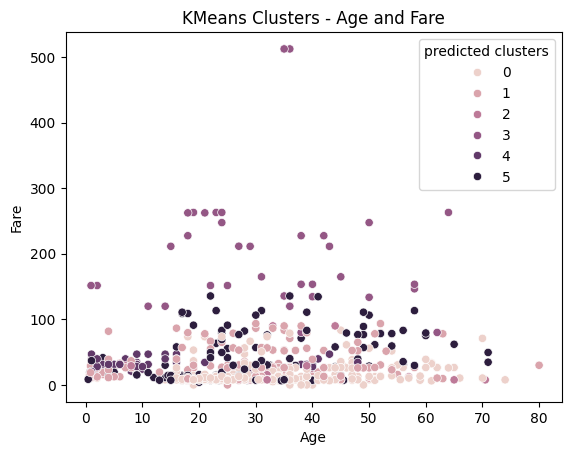

In [19]:
# create 2 scatter plots with variables of your choosing.
sns.scatterplot(data=df_scaled, x='Age', y='Fare', hue='predicted clusters')
plt.title('KMeans Clusters - Age and Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

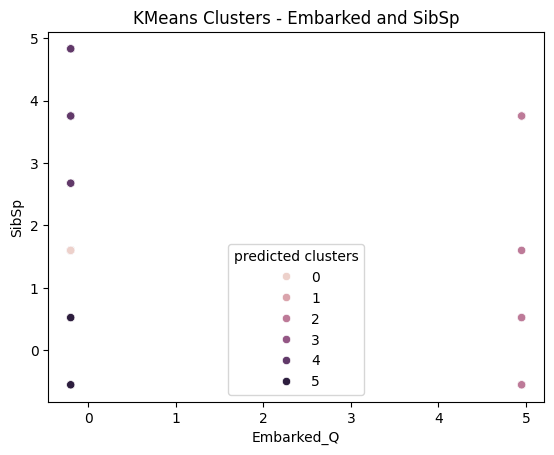

In [25]:
sns.scatterplot(data=df_scaled, x='Embarked_Q', y='SibSp', hue='predicted clusters')
plt.title('KMeans Clusters - Embarked and SibSp')
plt.xlabel('Embarked_Q')
plt.ylabel('SibSp')
plt.show()

At least with age and far, the datapoints don't seem to be very seperated. with Sibsp and embarked_Q, there is a clear separation. There seems to be clusters based on fare. There also seems to be clusters based on embarked and the number of siblings.

## Task 4c

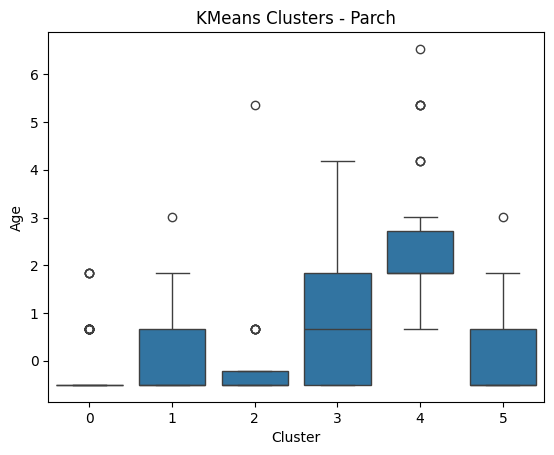

In [38]:
#create 2  boxplots with variables of your choosing.
sns.boxplot(data=df_scaled, x='predicted clusters', y='Parch')
plt.title('KMeans Clusters - Parch')
plt.xlabel('Cluster')
plt.ylabel('Age')
plt.show()

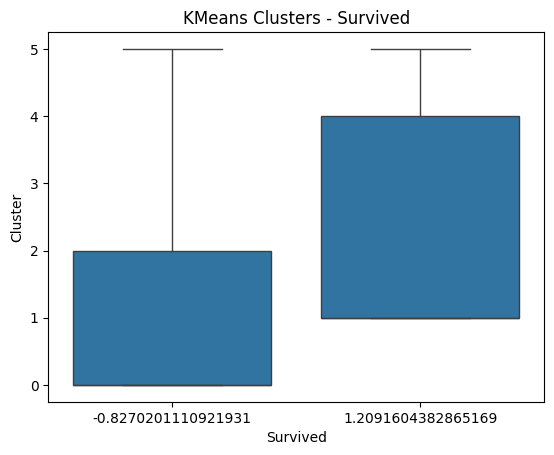

In [40]:
sns.boxplot(data=df_scaled, x='Survived', y='predicted clusters')
plt.title('KMeans Clusters - Survived')
plt.xlabel('Survived')
plt.ylabel('Cluster')
plt.show()

I notice that there is a lot of some overlap with survived. There seems to be better some with Parch, though still much overlap. Looking at the Survived boxplot, Cluster 3 is different from cluster 0. Cluster 1 and 2 seem to be similar.

# Task **5**

In [42]:
# fit and transform scaled data with PCA
pca = PCA(n_components=3)
pca_scaled = pca.fit_transform(df_scaled)

In [43]:
# save in a new df
pca_df = pd.DataFrame(data=pca_scaled, columns=['PC1', 'PC2', 'PC3'])

In [44]:
print(pca.explained_variance_ratio_)

[0.35972736 0.13743263 0.11754197]


In [46]:
print(np.cumsum(pca.explained_variance_ratio_))

[0.35972736 0.49715998 0.61470195]


In [47]:
print(sum(pca.explained_variance_ratio_))

0.6147019541776148


Together, all PCs explain about 60% of variance.

# Task 6

In [48]:
# fit new kmeans with pca_df
kmeans_pca = KMeans(n_clusters=6).fit(pca_df)

In [49]:
# predict the clusters
kmeans_pca_pred = kmeans_pca.predict(pca_df)

In [50]:
# save in as the new 'predicted clusters' column
pca_df['predicted clusters'] = kmeans_pca_pred

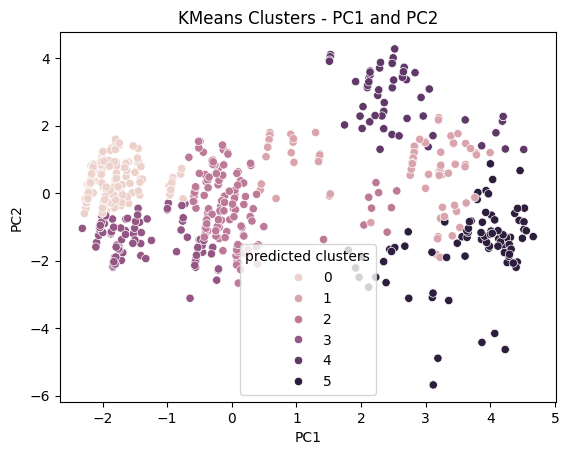

In [51]:
# plot pc1 and pc2 with scatterplot
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='predicted clusters')
plt.title('KMeans Clusters - PC1 and PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

It is much easier to tell the clusters apart this way, though perhaps more difficult to tell which features are a part of what PC. There are several distinct clusters, with a bit of overlap in some clusters, specifically 1, 4, and 5, I think. Each PC is taking into account general trends in the data as indeicated by each Principle componant, rather than only taking into account single features of our choosing like in part four.

In [ ]:
!jupyter nbconvert --to html 'your_notebook_name.ipynb'